Best Parameters: {'max_depth': 15, 'min_samples_split': 2}

Decision Tree
Train Accuracy: 0.7233035714285714
Test Accuracy: 0.5935714285714285

Random Forest
Train Accuracy: 0.887875
Test Accuracy: 0.7075714285714285

AdaBoost
Train Accuracy: 0.4341964285714286
Test Accuracy: 0.43364285714285716

Overfitting Check:
Decision Tree is overfitting
Random Forest is overfitting
AdaBoost is well-generalized

Final Decision Tree Results:
Accuracy: 0.5935714285714285

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.71      0.73      1343
           1       0.39      0.87      0.54      1600
           2       0.70      0.60      0.64      1380
           3       0.66      0.54      0.60      1433
           4       0.64      0.51      0.57      1295
           5       0.58      0.42      0.49      1273
           6       0.72      0.63      0.68      1396
           7       0.77      0.58      0.66      1503
           8       0.56  

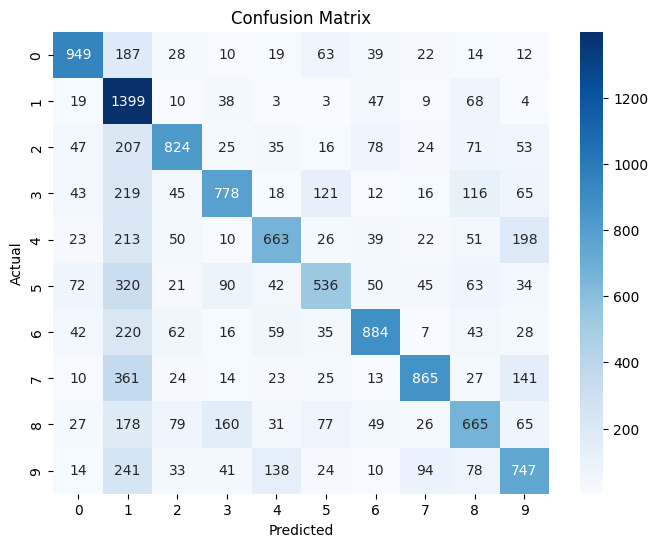

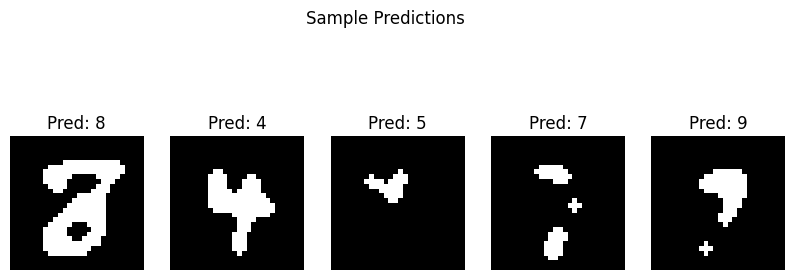

In [ ]:
# -------------------------------
# IMPORT LIBRARIES
# -------------------------------
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()

# -------------------------------
# 2. IMAGE PROCESSING
# -------------------------------
images = X.reshape(-1, 28, 28)
processed_images = []

for img in images:

    # Image normalization (contrast stretching)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

    # Convert to uint8 for thresholding
    img = img.astype(np.uint8)

    # Thresholding (Segmentation)
    _, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

    # Morphological operations
    kernel = np.ones((3,3), np.uint8)
    img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

    # Median filtering (noise removal)
    img = cv2.medianBlur(img, 3)

    # Flatten image
    processed_images.append(img.flatten())

X_processed = np.array(processed_images)

# -------------------------------
# 3. TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. HYPERPARAMETER TUNING (Decision Tree)
# -------------------------------
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# -------------------------------
# 5. MODEL COMPARISON
# -------------------------------
models = {
    "Decision Tree": best_dt,
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "AdaBoost": AdaBoostClassifier(n_estimators=50)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results[name] = (train_acc, test_acc)

    print(f"\n{name}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)

# -------------------------------
# 6. OVERFITTING DETECTION
# -------------------------------
print("\nOverfitting Check:")
for name, (train_acc, test_acc) in results.items():
    if train_acc - test_acc > 0.05:
        print(f"{name} is overfitting")
    else:
        print(f"{name} is well-generalized")

# -------------------------------
# 7. FINAL MODEL (Decision Tree)
# -------------------------------
final_model = best_dt
y_pred = final_model.predict(X_test)

# -------------------------------
# 8. EVALUATION
# -------------------------------
print("\nFinal Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# 9. CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# 10. VISUALIZATION OF DIGITS
# -------------------------------
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.suptitle("Sample Predictions")
plt.show()

Dataset shape: (70000, 784)
Training samples: 35000
Testing samples: 35000

Overall Accuracy: 85.7714 %

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3463
           1       0.92      0.96      0.94      3927
           2       0.82      0.85      0.83      3520
           3       0.83      0.79      0.81      3551
           4       0.84      0.86      0.85      3333
           5       0.82      0.78      0.80      3144
           6       0.89      0.87      0.88      3490
           7       0.90      0.88      0.89      3718
           8       0.81      0.80      0.80      3344
           9       0.80      0.84      0.82      3510

    accuracy                           0.86     35000
   macro avg       0.86      0.86      0.86     35000
weighted avg       0.86      0.86      0.86     35000



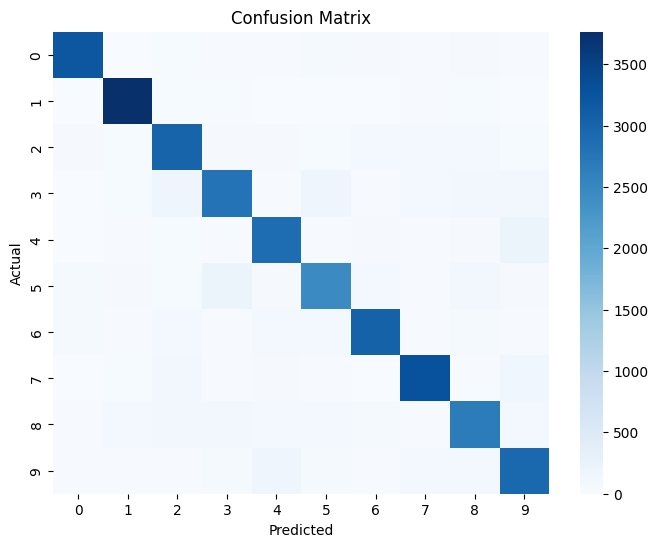

Digit 0 Accuracy: 92.2%
Digit 1 Accuracy: 95.9%
Digit 2 Accuracy: 85.37%
Digit 3 Accuracy: 78.65%
Digit 4 Accuracy: 86.26%
Digit 5 Accuracy: 77.96%
Digit 6 Accuracy: 86.96%
Digit 7 Accuracy: 88.33%
Digit 8 Accuracy: 79.93%
Digit 9 Accuracy: 83.9%


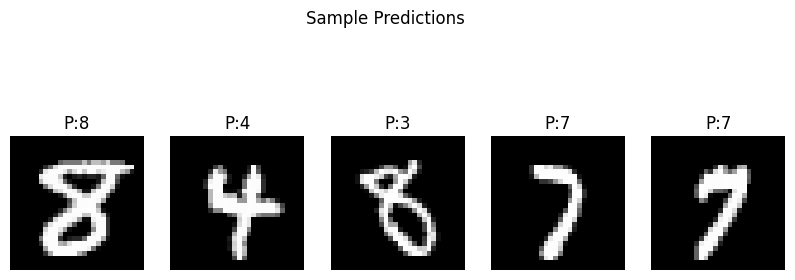

In [ ]:
# -------------------------------
# IMPORT LIBRARIES
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# 1. LOAD DATASET (MNIST / Kaggle style)
# -------------------------------
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.to_numpy()          # 784 pixel features
y = mnist.target.astype(int)       # labels 0–9

print("Dataset shape:", X.shape)

# -------------------------------
# 2. IMAGE REPRESENTATION
# (28x28 grayscale → flatten to 784 features)
# Concept: Digital Image Representation
# -------------------------------
images = X.reshape(-1, 28, 28)

# -------------------------------
# 3. NORMALIZATION
# Concept: Intensity Normalization (0–255 → 0–1)
# -------------------------------
X = X / 255.0

# -------------------------------
# 4. TRAIN-TEST SPLIT
# (similar to paper: training + testing sets)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# -------------------------------
# 5. MODEL TRAINING (Decision Tree)
# Concept: Supervised Learning
# -------------------------------
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
dt.fit(X_train, y_train)

# -------------------------------
# 6. PREDICTION
# -------------------------------
y_pred = dt.predict(X_test)

# -------------------------------
# 7. OVERALL ACCURACY
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nOverall Accuracy:", np.round(accuracy * 100, 4), "%")

# -------------------------------
# 8. CLASSIFICATION REPORT
# -------------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# 9. CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# 10. PER-DIGIT ACCURACY (IMPORTANT - FROM PAPER)
# -------------------------------
digit_accuracy = {}

for digit in range(10):
    idx = (y_test == digit)
    acc = accuracy_score(y_test[idx], y_pred[idx])
    digit_accuracy[digit] = acc * 100
    print(f"Digit {digit} Accuracy: {np.round(acc*100, 2)}%")

# -------------------------------
# 11. VISUALIZATION OF PREDICTIONS
# -------------------------------
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P:{y_pred[i]}")
    plt.axis('off')

plt.suptitle("Sample Predictions")
plt.show()

Dataset Shape: (70000, 784)
Train Size: (49000, 784)
Test Size: (21000, 784)

Initial Decision Tree:
Train Accuracy: 1.0
Test Accuracy: 0.8555238095238096
Overfitting Detected 

Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

Tuned Decision Tree Accuracy: 0.8674761904761905

Model Comparison:
Decision Tree: 0.8674761904761905
Random Forest: 0.9621904761904762
AdaBoost: 0.6557142857142857


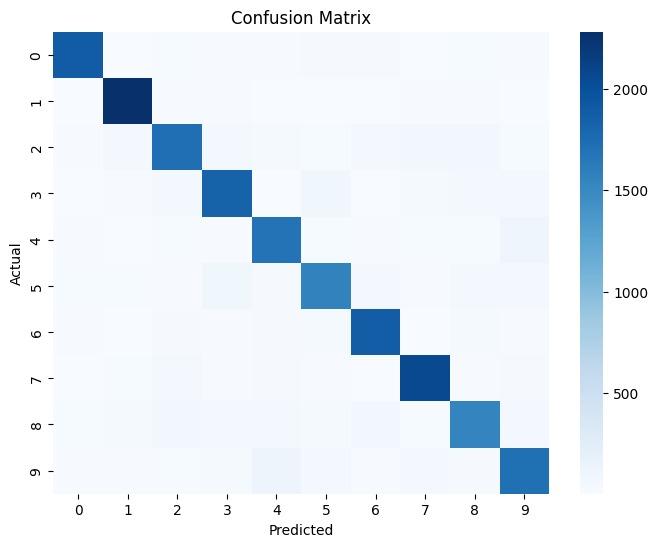


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2058
           1       0.93      0.97      0.95      2364
           2       0.85      0.81      0.83      2133
           3       0.85      0.84      0.85      2176
           4       0.83      0.87      0.85      1936
           5       0.83      0.82      0.82      1915
           6       0.88      0.90      0.89      2088
           7       0.89      0.92      0.90      2248
           8       0.83      0.78      0.80      1992
           9       0.83      0.82      0.82      2090

    accuracy                           0.87     21000
   macro avg       0.87      0.87      0.87     21000
weighted avg       0.87      0.87      0.87     21000


Per Digit Accuracy:
Digit 0: 92.23%
Digit 1: 96.62%
Digit 2: 81.06%
Digit 3: 84.33%
Digit 4: 87.35%
Digit 5: 81.72%
Digit 6: 90.28%
Digit 7: 91.86%
Digit 8: 77.86%
Digit 9: 82.01%


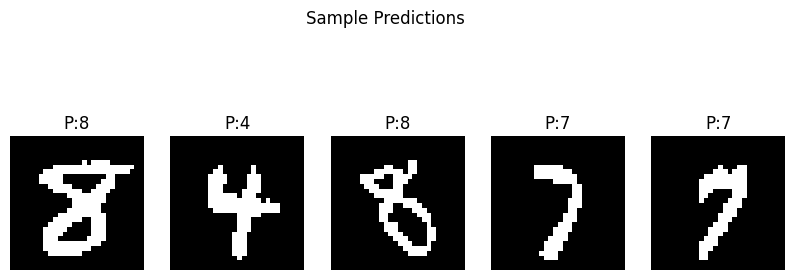


Insights:
- Some digits like 5 and 8 may be misclassified due to similar shapes.
- Decision Tree performs well but may not capture pixel relationships.
- Ensemble models (RF, AdaBoost) usually give better accuracy.


In [ ]:
# ================================
# IMPORT LIBRARIES
# ================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ================================
# 1. LOAD DATASET (MNIST)
# ================================
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.to_numpy()
y = mnist.target.astype(int)

print("Dataset Shape:", X.shape)

# ================================
# 2. IMAGE REPRESENTATION
# Concept: Digital Image (28x28 → 784 pixels)
# ================================
images = X.reshape(-1, 28, 28)

# ================================
# 3. NORMALIZATION
# Concept: Intensity Normalization (0–255 → 0–1)
# ================================
X = X / 255.0

# ================================
# 4. THRESHOLDING (Image Processing)
# Concept: Binary Segmentation
# ================================
X_thresh = (X > 0.5).astype(int)

# ================================
# 5. TRAIN-TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_thresh, y, test_size=0.3, random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

# ================================
# 6. INITIAL DECISION TREE
# ================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nInitial Decision Tree:")
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Overfitting Detection
if train_acc - test_acc > 0.05:
    print("Overfitting Detected ")
else:
    print("No Overfitting ")

# ================================
# 7. HYPERPARAMETER TUNING
# ================================
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid, cv=3, scoring='accuracy')

grid.fit(X_train, y_train)

best_dt = grid.best_estimator_
print("\nBest Parameters:", grid.best_params_)

# ================================
# 8. FINAL DECISION TREE RESULTS
# ================================
y_test_pred_dt = best_dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_test_pred_dt)

print("\nTuned Decision Tree Accuracy:", dt_acc)

# ================================
# 9. MODEL COMPARISON
# ================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
ada_acc = accuracy_score(y_test, ada_pred)

print("\nModel Comparison:")
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)
print("AdaBoost:", ada_acc)

# ================================
# 10. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_test_pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 11. CLASSIFICATION REPORT
# ================================
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_dt))

# ================================
# 12. PER-DIGIT ACCURACY (IMPORTANT)
# ================================
print("\nPer Digit Accuracy:")
for digit in range(10):
    idx = (y_test == digit)
    acc = accuracy_score(y_test[idx], y_test_pred_dt[idx])
    print(f"Digit {digit}: {round(acc*100,2)}%")

# ================================
# 13. VISUALIZATION
# ================================
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P:{y_test_pred_dt[i]}")
    plt.axis('off')

plt.suptitle("Sample Predictions")
plt.show()

# ================================
# 14. RESULT ANALYSIS (PRINT INSIGHTS)
# ================================
print("\nInsights:")
print("- Some digits like 5 and 8 may be misclassified due to similar shapes.")
print("- Decision Tree performs well but may not capture pixel relationships.")
print("- Ensemble models (RF, AdaBoost) usually give better accuracy.")